Le travail a ete divise en 2 grandes parties: 
- la premiere partie(EDA) c'est pour nous aider a comprendre les données dans leurs organisation et leurs structures. Comme dans tous projet de data science, c'est une etape importante a ne pas negliger.
- La deuxieme partie concerne le coeurs du projet. C'est a dire la finalisation du pretraitement, la modelisation, l'entrainement suivie de l'evaluation des performance, la prediction et en fin la generation du **CAM(class activation Map)**. C'est dans cette partie que nous executons le code de la version du **chexNet** que nous avons utilisé pour ce projet.

# 1. EDA
Nous commencons par un peu d'exploration et de visualization pour mieux comprendre nos données.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Import de toutes les librairies necessaires.

In [2]:
import time
import sys

import random
import matplotlib.pylab as plt
import cv2
import matplotlib.gridspec as gridspec
import seaborn as sns
import zlib
import itertools
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.nn.functional as tfunc
import torch.nn.functional as func
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torchvision.transforms as transforms
import torchvision

from glob import glob
from PIL import Image

## Chargement des données.

In [3]:
PATH = os.path.abspath(os.path.join('..', 'input/sample/'))
SOURCE_IMAGES = os.path.join(PATH, "sample", "images")
images = glob(os.path.join(SOURCE_IMAGES, "*.png"))

images[0:10]

['/kaggle/input/sample/sample/images/00004490_006.png',
 '/kaggle/input/sample/sample/images/00020106_005.png',
 '/kaggle/input/sample/sample/images/00003239_001.png',
 '/kaggle/input/sample/sample/images/00013424_004.png',
 '/kaggle/input/sample/sample/images/00009910_000.png',
 '/kaggle/input/sample/sample/images/00021610_000.png',
 '/kaggle/input/sample/sample/images/00010734_000.png',
 '/kaggle/input/sample/sample/images/00017212_000.png',
 '/kaggle/input/sample/sample/images/00028211_016.png',
 '/kaggle/input/sample/sample/images/00021610_034.png']

In [4]:
labels = pd.read_csv('../input/sample/sample_labels.csv')
labels.head(10)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168
5,00000040_003.png,Consolidation|Mass,3,40,068Y,M,PA,2500,2048,0.168,0.168
6,00000042_002.png,No Finding,2,42,071Y,M,AP,3056,2544,0.139,0.139
7,00000057_001.png,No Finding,1,57,071Y,M,AP,3056,2544,0.139,0.139
8,00000061_002.png,Effusion,2,61,077Y,M,PA,2992,2991,0.143,0.143
9,00000061_019.png,No Finding,19,61,077Y,M,AP,3056,2544,0.139,0.139


## Visualization des données.

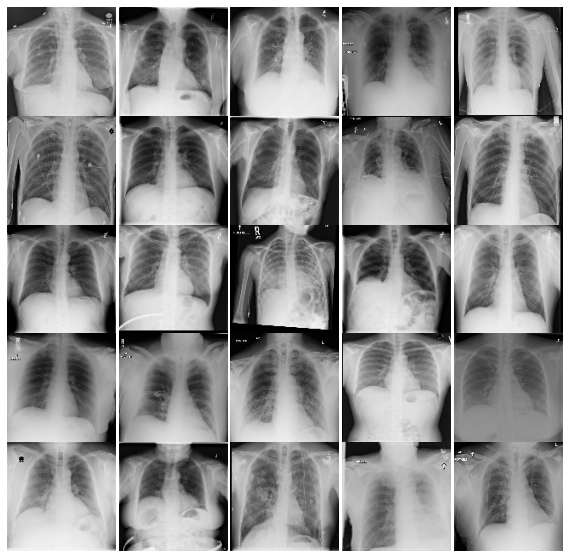

In [5]:
multipleImages = glob('/kaggle/input/sample/sample/images/**')
i_ = 0
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
for l in multipleImages[:25]:
    im = cv2.imread(l)
    im = cv2.resize(im, (128, 128)) 
    plt.subplot(5, 5, i_+1) #.set_title(l)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); plt.axis('off')
    i_ += 1

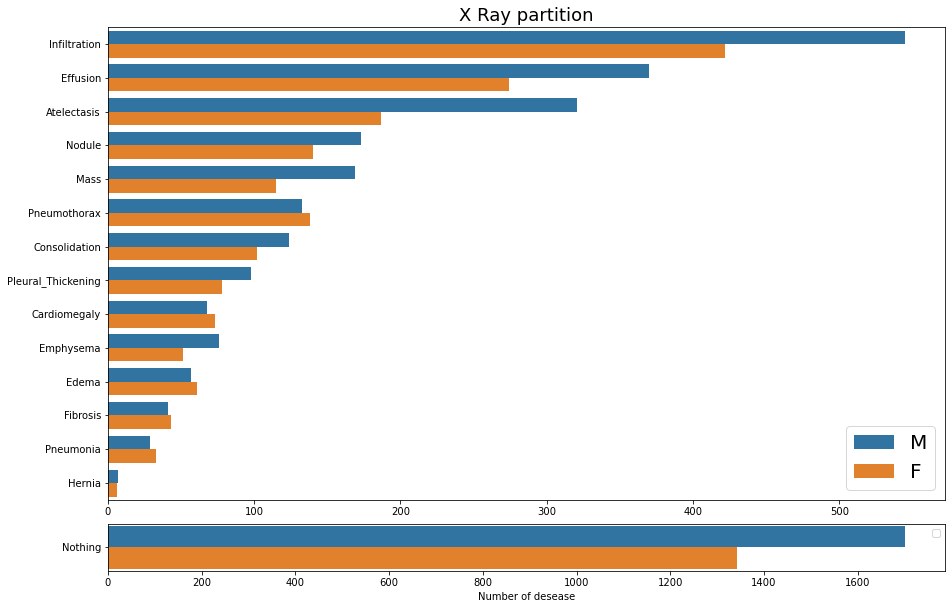

In [6]:
#drop unused columns
labels = labels[['Image Index','Finding Labels','Follow-up #','Patient ID',
                 'Patient Age','Patient Gender']]
#create new columns for each decease
pathology_list = ['Cardiomegaly','Emphysema','Effusion','Hernia','Nodule','Pneumothorax',
                  'Atelectasis','Pleural_Thickening','Mass','Edema','Consolidation',
                  'Infiltration','Fibrosis','Pneumonia']
for pathology in pathology_list :
    labels[pathology] = labels['Finding Labels'].apply(lambda x: 1 if pathology in x else 0)
#remove Y after age
labels['Age']=labels['Patient Age'].apply(lambda x: x[:-1]).astype(int)

plt.figure(figsize=(15,10))
gs = gridspec.GridSpec(8,1)
ax1 = plt.subplot(gs[:7, :])
ax2 = plt.subplot(gs[7, :])
data1 = pd.melt(labels,
             id_vars=['Patient Gender'],
             value_vars = list(pathology_list),
             var_name = 'Category',
             value_name = 'Count')
data1 = data1.loc[data1.Count>0]
g=sns.countplot(y='Category',hue='Patient Gender',data=data1, ax=ax1, 
                order = data1['Category'].value_counts().index)
ax1.set( ylabel="",xlabel="")
ax1.legend(fontsize=20)
ax1.set_title('X Ray partition',fontsize=18);

labels['Nothing']=labels['Finding Labels'].apply(lambda x: 1 if 'No Finding' in x else 0)

data2 = pd.melt(labels,
             id_vars=['Patient Gender'],
             value_vars = list(['Nothing']),
             var_name = 'Category',
             value_name = 'Count')
data2 = data2.loc[data2.Count>0]
g=sns.countplot(y='Category',hue='Patient Gender',data=data2,ax=ax2)
ax2.set( ylabel="",xlabel="Number of desease")
ax2.legend('')
plt.subplots_adjust(hspace=.5)


In [7]:
print(labels[pathology_list])

      Cardiomegaly  Emphysema  Effusion  Hernia  Nodule  Pneumothorax  \
0                0          1         0       0       0             1   
1                1          1         0       0       0             0   
2                0          0         0       0       0             0   
3                0          0         0       0       0             0   
4                1          0         1       0       0             0   
...            ...        ...       ...     ...     ...           ...   
5601             0          0         0       0       0             0   
5602             1          1         1       0       0             0   
5603             0          0         0       0       0             0   
5604             0          0         0       0       0             0   
5605             0          0         0       0       0             0   

      Atelectasis  Pleural_Thickening  Mass  Edema  Consolidation  \
0               0                   1     0      0    

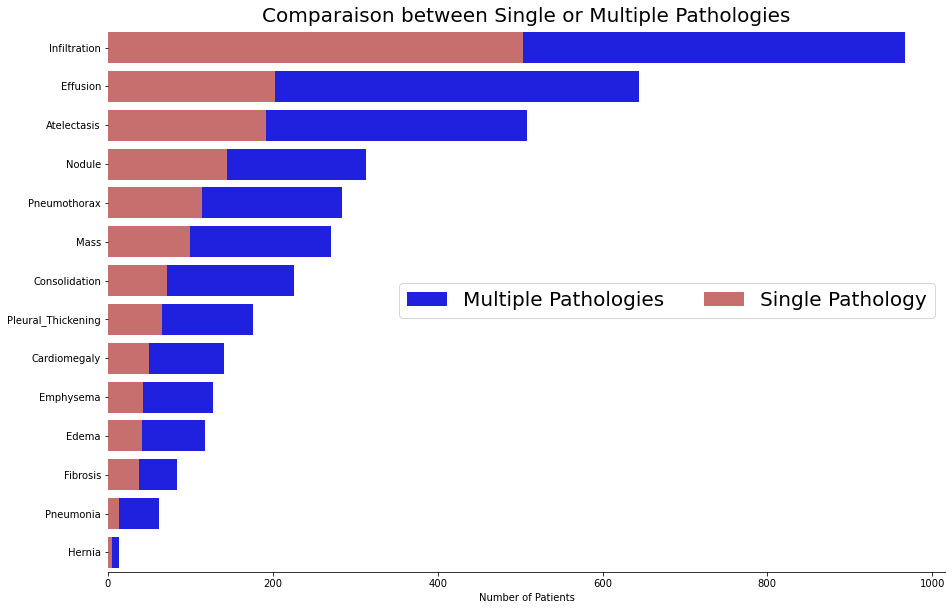

In [8]:
df=labels
data=df.groupby('Finding Labels').count().sort_values('Patient ID',ascending=False)
df1=data[['|' in index for index in data.index]].copy()
df2=data[['|' not in index for index in data.index]]
df2=df2[['No Finding' not in index for index in df2.index]]
df2['Finding Labels']=df2.index.values
df1['Finding Labels']=df1.index.values

f, ax = plt.subplots(sharex=True,figsize=(15, 10))
g=sns.countplot(y='Category',data=data1, ax=ax, 
                order=data1['Category'].value_counts().index,color='b',
                label="Multiple Pathologies")
sns.set_color_codes("muted")
g=sns.barplot(x='Patient ID',y='Finding Labels',data=df2, ax=ax, 
              color="r",label="Single Pathology")
ax.legend(ncol=2, loc="center right", frameon=True,fontsize=20)
ax.set( ylabel="",xlabel="Number of Patients")
ax.set_title("Comparaison between Single or Multiple Pathologies",fontsize=20)      
sns.despine(left=True)

## Pretraitement des données.

In [9]:
y = pd.concat([labels["Image Index"], labels[pathology_list]], axis=1)
y.head()

,Image Index,Cardiomegaly,Emphysema,Effusion,Hernia,Nodule,Pneumothorax,Atelectasis,Pleural_Thickening,Mass,Edema,Consolidation,Infiltration,Fibrosis,Pneumonia
0,00000013_005.png,0,1,0,0,0,1,0,1,0,0,0,1,0,0
1,00000013_026.png,1,1,0,0,0,0,0,0,0,0,0,0,0,0
2,00000017_001.png,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,00000030_001.png,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,00000032_001.png,1,0,1,0,0,0,0,0,0,1,0,0,0,0


In [10]:
Y_train, Y_test = train_test_split(y, test_size=0.2, random_state=42, shuffle=True)
Y_train, Y_val = train_test_split(Y_train, test_size=0.1, random_state=42, shuffle=True)
print(Y_train.shape)
print(Y_test.shape)
print(Y_val.shape)

Y_train.to_csv('train_1.txt', sep='\t', header=False, index=False)
Y_val.to_csv('val_1.txt', sep='\t', header=False, index=False)
Y_test.to_csv('test_1.txt', sep='\t', header=False, index=False)

(4035, 15)
(1122, 15)
(449, 15)


# 2. DEEP LEARNING

In [11]:
class DatasetGenerator (Dataset):
    
    def __init__ (self, pathImageDirectory, pathDatasetFile, transform):
    
        self.listImagePaths = []
        self.listImageLabels = []
        self.transform = transform
    
        #---- Open file, get image paths and labels
    
        fileDescriptor = open(pathDatasetFile, "r")
        
        #---- get into the loop
        line = True
        
        while line:
                
            line = fileDescriptor.readline()
            
            #--- if not empty
            if line:
          
                lineItems = line.split()
                
                imagePath = os.path.join(pathImageDirectory, lineItems[0])
                imageLabel = lineItems[1:]
                imageLabel = [int(i) for i in imageLabel]
                
                self.listImagePaths.append(imagePath)
                self.listImageLabels.append(imageLabel)   
            
        fileDescriptor.close()
    
    #-------------------------------------------------------------------------------- 
    
    def __getitem__(self, index):
        
        imagePath = self.listImagePaths[index]
        
        imageData = Image.open(imagePath).convert('RGB')
        imageLabel= torch.FloatTensor(self.listImageLabels[index])
        
        if self.transform != None: imageData = self.transform(imageData)
        
        return imageData, imageLabel
        
    #-------------------------------------------------------------------------------- 
    
    def __len__(self):
        
        return len(self.listImagePaths)

In [12]:
class DenseNet121(nn.Module):

    def __init__(self, classCount, isTrained):
        super(DenseNet121, self).__init__()
        self.densenet121 = torchvision.models.densenet121(pretrained=isTrained)

        kernelCount = self.densenet121.classifier.in_features
        self.densenet121.classifier = nn.Sequential(nn.Linear(kernelCount, classCount), nn.Sigmoid())

    def forward(self, x):
        x = self.densenet121(x)
        return x

class DenseNet169(nn.Module):
    
    def __init__(self, classCount, isTrained):
        super(DenseNet169, self).__init__()
        self.densenet169 = torchvision.models.densenet169(pretrained=isTrained)
        
        kernelCount = self.densenet169.classifier.in_features
        self.densenet169.classifier = nn.Sequential(nn.Linear(kernelCount, classCount), nn.Sigmoid())
        
    def forward (self, x):
        x = self.densenet169(x)
        return x
    
class DenseNet201(nn.Module):
    
    def __init__ (self, classCount, isTrained):
        super(DenseNet201, self).__init__()
        self.densenet201 = torchvision.models.densenet201(pretrained=isTrained)
        
        kernelCount = self.densenet201.classifier.in_features
        self.densenet201.classifier = nn.Sequential(nn.Linear(kernelCount, classCount), nn.Sigmoid())
        
    def forward (self, x):
        x = self.densenet201(x)
        return x

In [22]:
import gc 
# Your code with pytorch using GPU


class ChexnetTrainer ():

    #---- Train the densenet network 
    #---- pathDirData - path to the directory that contains images
    #---- pathFileTrain - path to the file that contains image paths and label pairs (training set)
    #---- pathFileVal - path to the file that contains image path and label pairs (validation set)
    #---- nnArchitecture - model architecture 'DENSE-NET-121', 'DENSE-NET-169' or 'DENSE-NET-201'
    #---- nnIsTrained - if True, uses pre-trained version of the network (pre-trained on imagenet)
    #---- nnClassCount - number of output classes 
    #---- trBatchSize - batch size
    #---- trMaxEpoch - number of epochs
    #---- transResize - size of the image to scale down to (not used in current implementation)
    #---- transCrop - size of the cropped image 
    #---- launchTimestamp - date/time, used to assign unique name for the checkpoint file
    #---- checkpoint - if not None loads the model and continues training
    
    def train (pathDirData, pathFileTrain, pathFileVal, nnArchitecture, nnIsTrained, nnClassCount,
               trBatchSize, trMaxEpoch, transResize, transCrop, launchTimestamp, checkpoint):
 
        #-------------------- SETTINGS: NETWORK ARCHITECTURE
        if nnArchitecture == 'DENSE-NET-121': model = DenseNet121(nnClassCount, nnIsTrained).cuda()
        elif nnArchitecture == 'DENSE-NET-169': model = DenseNet169(nnClassCount, nnIsTrained).cuda()
        elif nnArchitecture == 'DENSE-NET-201': model = DenseNet201(nnClassCount, nnIsTrained).cuda()
        
        model = torch.nn.DataParallel(model).cuda()
                
        #-------------------- SETTINGS: DATA TRANSFORMS
        normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        
        transformList = []
        transformList.append(transforms.RandomResizedCrop(transCrop))
        transformList.append(transforms.RandomHorizontalFlip())
        transformList.append(transforms.ToTensor())
        transformList.append(normalize)      
        transformSequence=transforms.Compose(transformList)

        #-------------------- SETTINGS: DATASET BUILDERS
        datasetTrain = DatasetGenerator(pathImageDirectory=pathDirData, 
                                        pathDatasetFile=pathFileTrain, 
                                        transform=transformSequence)
        datasetVal =   DatasetGenerator(pathImageDirectory=pathDirData, 
                                        pathDatasetFile=pathFileVal,
                                        transform=transformSequence)
              
        dataLoaderTrain = DataLoader(dataset=datasetTrain, batch_size=trBatchSize,
                                     shuffle=True,  num_workers=0, pin_memory=True)
        dataLoaderVal = DataLoader(dataset=datasetVal, batch_size=trBatchSize, 
                                   shuffle=False, num_workers=0, pin_memory=True)
        
        #-------------------- SETTINGS: OPTIMIZER & SCHEDULER
        optimizer = optim.Adam (model.parameters(), lr=0.0001, betas=(0.9, 0.999), 
                                eps=1e-08, weight_decay=1e-5)
        scheduler = ReduceLROnPlateau(optimizer, factor = 0.1, patience = 5, mode = 'min')
                
        #-------------------- SETTINGS: LOSS
        loss = torch.nn.BCELoss(size_average = True)
        
        #---- Load checkpoint 
        if checkpoint != None:
            modelCheckpoint = torch.load(checkpoint)
            model.load_state_dict(modelCheckpoint['state_dict'])
            optimizer.load_state_dict(modelCheckpoint['optimizer'])

        
        #---- TRAIN THE NETWORK
        
        lossMIN = 100000
        
        for epochID in range (0, trMaxEpoch):
            
            timestampTime = time.strftime("%H%M%S")
            timestampDate = time.strftime("%d%m%Y")
            timestampSTART = timestampDate + '-' + timestampTime
                         
            ChexnetTrainer.epochTrain (model, dataLoaderTrain, optimizer, scheduler, 
                                       trMaxEpoch, nnClassCount, loss)
            lossVal, losstensor = ChexnetTrainer.epochVal (model, dataLoaderVal, optimizer, 
                                                           scheduler, trMaxEpoch, 
                                                           nnClassCount, loss)
            
            timestampTime = time.strftime("%H%M%S")
            timestampDate = time.strftime("%d%m%Y")
            timestampEND = timestampDate + '-' + timestampTime
            
            scheduler.step(losstensor.data)
            
            if lossVal < lossMIN:
                lossMIN = lossVal    
                torch.save({'epoch': epochID + 1, 'state_dict': model.state_dict(), 'best_loss': lossMIN, 'optimizer' : optimizer.state_dict()}, 'm-' + launchTimestamp + '.pth.tar')
                print ('Epoch [' + str(epochID + 1) + '] [save] [' + timestampEND + '] loss= ' + str(lossVal))
            else:
                print ('Epoch [' + str(epochID + 1) + '] [----] [' + timestampEND + '] loss= ' + str(lossVal))
                     
    #-------------------------------------------------------------------------------- 
       
    def epochTrain (model, dataLoader, optimizer, scheduler, epochMax, classCount, loss):
        
        model.train()
        
        for batchID, (input, target) in enumerate (dataLoader):
                        
            target = target.cuda(non_blocking=True)
                 
            varInput = torch.autograd.Variable(input)
            varTarget = torch.autograd.Variable(target)         
            varOutput = model(varInput)
            
            lossvalue = loss(varOutput, varTarget)
                       
            optimizer.zero_grad()
            lossvalue.backward()
            optimizer.step()
            
    #-------------------------------------------------------------------------------- 
        
    def epochVal (model, dataLoader, optimizer, scheduler, epochMax, classCount, loss):
        
        model.eval ()
        
        lossVal = 0
        lossValNorm = 0
        
        losstensorMean = 0
        
        with torch.no_grad():
            for i, (input, target) in enumerate (dataLoader):

                target = target.cuda(non_blocking=True)

                varInput = torch.autograd.Variable(input)
                varTarget = torch.autograd.Variable(target)    
                varOutput = model(varInput)

                losstensor = loss(varOutput, varTarget)
                losstensorMean += losstensor

                lossVal += losstensor.item()
                lossValNorm += 1
            
        outLoss = lossVal / lossValNorm
        losstensorMean = losstensorMean / lossValNorm
        
        return outLoss, losstensorMean
               
    #--------------------------------------------------------------------------------     
     
    #---- Computes area under ROC curve 
    #---- dataGT - ground truth data
    #---- dataPRED - predicted data
    #---- classCount - number of classes
    
    def computeAUROC (dataGT, dataPRED, classCount):
        
        outAUROC = []
        
        datanpGT = dataGT.cpu().numpy()
        datanpPRED = dataPRED.cpu().numpy()
        
        for i in range(classCount):
            outAUROC.append(roc_auc_score(datanpGT[:, i], datanpPRED[:, i]))
            
        return outAUROC
        
        
    #--------------------------------------------------------------------------------  
    
    #---- Test the trained network 
    #---- pathDirData - path to the directory that contains images
    #---- pathFileTrain - path to the file that contains image paths and label pairs (training set)
    #---- pathFileVal - path to the file that contains image path and label pairs (validation set)
    #---- nnArchitecture - model architecture 'DENSE-NET-121', 'DENSE-NET-169' or 'DENSE-NET-201'
    #---- nnIsTrained - if True, uses pre-trained version of the network (pre-trained on imagenet)
    #---- nnClassCount - number of output classes 
    #---- trBatchSize - batch size
    #---- trMaxEpoch - number of epochs
    #---- transResize - size of the image to scale down to (not used in current implementation)
    #---- transCrop - size of the cropped image 
    #---- launchTimestamp - date/time, used to assign unique name for the checkpoint file
    #---- checkpoint - if not None loads the model and continues training
    
    def test (pathDirData, pathFileTest, pathModel, nnArchitecture, nnClassCount, 
              nnIsTrained, trBatchSize, transResize, transCrop, launchTimeStamp):   
        
        
        CLASS_NAMES = [ 'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia',
                'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']
        
        cudnn.benchmark = True
        
        #-------------------- SETTINGS: NETWORK ARCHITECTURE, MODEL LOAD
        if nnArchitecture == 'DENSE-NET-121': model = DenseNet121(nnClassCount, nnIsTrained).cuda()
        elif nnArchitecture == 'DENSE-NET-169': model = DenseNet169(nnClassCount, nnIsTrained).cuda()
        elif nnArchitecture == 'DENSE-NET-201': model = DenseNet201(nnClassCount, nnIsTrained).cuda()
        
        model = torch.nn.DataParallel(model).cuda() 
        
        modelCheckpoint = torch.load(pathModel)
        model.load_state_dict(modelCheckpoint['state_dict'])

        #-------------------- SETTINGS: DATA TRANSFORMS, TEN CROPS
        normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        
        #-------------------- SETTINGS: DATASET BUILDERS
        transformList = []
        transformList.append(transforms.Resize(transResize))
        transformList.append(transforms.TenCrop(transCrop))
        transformList.append(transforms.Lambda(lambda crops: torch.stack([transforms.ToTensor()(crop) for crop in crops])))
        transformList.append(transforms.Lambda(lambda crops: torch.stack([normalize(crop) for crop in crops])))
        transformSequence=transforms.Compose(transformList)
        
        datasetTest = DatasetGenerator(pathImageDirectory=pathDirData, 
                                       pathDatasetFile=pathFileTest, 
                                       transform=transformSequence)
        dataLoaderTest = DataLoader(dataset=datasetTest, batch_size=trBatchSize,
                                    num_workers=0, shuffle=False, pin_memory=True)
        
        outGT = torch.FloatTensor().cuda(non_blocking=True)
        outPRED = torch.FloatTensor().cuda(non_blocking=True)
       
        model.eval()
        with torch.no_grad():
            for i, (input, target) in enumerate(dataLoaderTest):

                #target = target.cuda()
                target = target.cuda(non_blocking=True)
                outGT = torch.cat((outGT, target), 0)

                bs, n_crops, c, h, w = input.size()

                varInput = torch.autograd.Variable(input.view(-1, c, h, w).cuda(), volatile=True)

                out = model(varInput)
                outMean = out.view(bs, n_crops, -1).mean(1)

                outPRED = torch.cat((outPRED, outMean.data), 0)

        aurocIndividual = ChexnetTrainer.computeAUROC(outGT, outPRED, nnClassCount)
        aurocMean = np.array(aurocIndividual).mean()
        
        print ('AUROC mean ', aurocMean)
        
        for i in range (0, len(aurocIndividual)):
            print (CLASS_NAMES[i], ' ', aurocIndividual[i])
        
     
        return

In [23]:
def main ():
    runTest()
    #runTrain()

def runTrain():
    
    DENSENET121 = 'DENSE-NET-121'
    DENSENET169 = 'DENSE-NET-169'
    DENSENET201 = 'DENSE-NET-201'
    
    timestampTime = time.strftime("%H%M%S")
    timestampDate = time.strftime("%d%m%Y")
    timestampLaunch = timestampDate + '-' + timestampTime
    
    #---- Path to the directory with images
    pathDirData = '/kaggle/input/sample/sample/sample/images'
    
    #---- Paths to the files with training, validation and testing sets.
    #---- Each file should contains pairs [path to image, output vector]
    #---- Example: images_011/00027736_001.png 0 0 0 0 0 0 0 0 0 0 0 0 0 0
    pathFileTrain = 'train_1.txt'
    pathFileVal = 'val_1.txt'
    pathFileTest = 'val_1.txt'
    
    #---- Neural network parameters: type of the network, is it pre-trained 
    #---- on imagenet, number of classes
    nnArchitecture = DENSENET121
    nnIsTrained = True
    nnClassCount = 14
    
    #---- Training settings: batch size, maximum number of epochs
    trBatchSize = 16
    trMaxEpoch = 50
    
    #---- Parameters related to image transforms: size of the down-scaled image, cropped image
    imgtransResize = 256
    imgtransCrop = 224
        
    pathModel = 'm-' + timestampLaunch + '.pth.tar'
    
    print ('Training NN architecture = ', nnArchitecture)
    ChexnetTrainer.train(pathDirData, pathFileTrain, pathFileVal, nnArchitecture, nnIsTrained, 
                         nnClassCount, trBatchSize, trMaxEpoch, imgtransResize, imgtransCrop, 
                         timestampLaunch, None)
    
    print ('Testing the trained model')
    ChexnetTrainer.test(pathDirData, pathFileTest, pathModel, nnArchitecture, nnClassCount, 
                        nnIsTrained, trBatchSize, imgtransResize, imgtransCrop, timestampLaunch)

#-------------------------------------------------------------------------------- 

def runTest():
    
    pathDirData = '/kaggle/input/sample/sample/sample/images'
    pathFileTest = './test_1.txt'
    nnArchitecture = 'DENSE-NET-121'
    nnIsTrained = True
    nnClassCount = 14
    trBatchSize = 16
    imgtransResize = 256
    imgtransCrop = 224
    
    pathModel = './m-25082020-060921.pth.tar'
    
    timestampLaunch = ''
    
    ChexnetTrainer.test(pathDirData, pathFileTest, pathModel, nnArchitecture, nnClassCount, 
                        nnIsTrained, trBatchSize, imgtransResize, imgtransCrop, timestampLaunch)

#-------------------------------------------------------------------------------- 

if __name__ == '__main__':
    main()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:234: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.


AUROC mean  0.7709995360930945
Atelectasis   0.7374292835383947
Cardiomegaly   0.8760358532048029
Effusion   0.8367156061368209
Infiltration   0.7047959487637772
Mass   0.6857499351827846
Nodule   0.8017537313432836
Pneumonia   0.7928226879574185
Pneumothorax   0.7503372835004559
Consolidation   0.7555763823805061
Edema   0.8352502882824281
Emphysema   0.8092350746268656
Fibrosis   0.6665759313133376
Pleural_Thickening   0.7718956792526275
Hernia   0.7698198198198198


In [ ]:
class HeatmapGenerator ():
    
    #---- Initialize heatmap generator
    #---- pathModel - path to the trained densenet model
    #---- nnArchitecture - architecture name DENSE-NET121, DENSE-NET169, DENSE-NET201
    #---- nnClassCount - class count, 14 for chxray-14

 
    def __init__ (self, pathModel, nnArchitecture, nnClassCount, transCrop):
       
        #---- Initialize the network
        if nnArchitecture == 'DENSE-NET-121': model = DenseNet121(nnClassCount, True).cuda()
        elif nnArchitecture == 'DENSE-NET-169': model = DenseNet169(nnClassCount, True).cuda()
        elif nnArchitecture == 'DENSE-NET-201': model = DenseNet201(nnClassCount, True).cuda()
          
        model = torch.nn.DataParallel(model).cuda()

        modelCheckpoint = torch.load(pathModel)
        model.load_state_dict(modelCheckpoint['state_dict'])

        self.model = model.module.densenet121.features
        self.model.eval()
        
        #---- Initialize the weights
        self.weights = list(self.model.parameters())[-2]

        #---- Initialize the image transform - resize + normalize
        normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        transformList = []
        transformList.append(transforms.Resize(transCrop))
        transformList.append(transforms.ToTensor())
        transformList.append(normalize)      
        
        self.transformSequence = transforms.Compose(transformList)
    
    #--------------------------------------------------------------------------------
     
    def generate (self, pathImageFile, pathOutputFile, transCrop):
        
        #---- Load image, transform, convert 
        imageData = Image.open(pathImageFile).convert('RGB')
        imageData = self.transformSequence(imageData)
        imageData = imageData.unsqueeze_(0)
        
        input = torch.autograd.Variable(imageData)
        
        self.model.cuda()
        output = self.model(input.cuda())
        
        #---- Generate heatmap
        heatmap = None
        for i in range (0, len(self.weights)):
            map = output[0,i,:,:]
            if i == 0: heatmap = self.weights[i] * map
            else: heatmap += self.weights[i] * map
        
        #---- Blend original and heatmap 
        npHeatmap = heatmap.cpu().data.numpy()

        imgOriginal = cv2.imread(pathImageFile, 1)
        imgOriginal = cv2.resize(imgOriginal, (transCrop, transCrop))
        
        cam = npHeatmap / np.max(npHeatmap)
        cam = cv2.resize(cam, (transCrop, transCrop))
        heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
              
        img = heatmap * 0.5 + imgOriginal
            
        cv2.imwrite(pathOutputFile, img)
        
#-------------------------------------------------------------------------------- 

pathInputImage = '/kaggle/input/sample/sample/sample/images/00004490_006.png'
pathOutputImage = 'heatmap.png'
pathModel = 'm-25012018-123527.pth.tar'

nnArchitecture = 'DENSE-NET-121'
nnClassCount = 14

transCrop = 224

h = HeatmapGenerator(pathModel, nnArchitecture, nnClassCount, transCrop)
h.generate(pathInputImage, pathOutputImage, transCrop)

### Reference: https://github.com/zoogzog/chexnet